In [1]:
import sys
import os
import numpy as np
import torch
from torchvision import transforms, utils
#sys.path.append("/mnt/home/avalenti/softw/mlDMFT/mlDMFT/mldmft/examples/1orbital/NN/")
git_path='/mnt/home/ipark/git/ml-dmft-fork/mlDMFT/'
sys.path.append(git_path)
from mldmft.models.orb1.NNet import FeedforwardNet


In [2]:
path=os.path.join(git_path, 'mldmft')
# print(path)

## I. NN-DMFT Loop

### 1) Set parameters for DMFT run using NNsolver
We start by picking values for $U$, $\mu$, $\beta$ and choosing an input hybridization function $\Delta$. In addition, we specify the tolarence for the DMFT convergence criterion, the maximum number of DMFT loops and the mixing parameter $\epsilon$, which is used for the DMFT self-consistency via 
$$ \Delta_{\rm new} = (1-\epsilon) \Delta_i + \epsilon \Delta_{i-1} $$

In [3]:
Uval = 7.0 
t = 1.0
mu = 3.5
beta = 50.0
beta0 = 70.0 #reference $\beta_0$ for dlr mesh

maxloops = 30   # number of DMFT iterations
etol = 1e-4     # DMFT SC loop convergence criteria, occupancy from G
epsilon = 0.05  # Delta mixing parameter


Next, we choose a starting hybridization function. This can either be done via TRIQS, and using the function ``DLR_to_NNinput'' to convert the format into the NN-input format, or by directly creating/loading a hybridization function in numpy and reshaping into the appropriate format. Concretely, the network takes as input an array of shape $A=(1, 2*n_{\tau}+3)$ with $A[0,:]=[\Re(\Delta_1), \Im(\Delta_1), ... \Re(\Delta_{n_{\tau}}), \Im(\Delta_{n_{\tau}}), U, \mu/U, \beta]$ . 

In [20]:
useSemiCircular = False

if useSemiCircular:
    from h5 import *
    from triqs.gf import *
    from triqs.gf.tools import *
    from triqs.gf.meshes import MeshDLRImFreq
    from mldmft.utils import DLR_to_NNinput 
    
    wmax_val = 10
    eps_val = 1e-13
    gf_struct = [('up', 1), ('down', 1)]
    dlr_freq_mesh = MeshDLRImFreq(beta=beta, statistic='Fermion', w_max=wmax_val, eps=eps_val)
    D = 1.0 
    Delta = BlockGf(mesh=dlr_freq_mesh, gf_struct=gf_struct)
    from triqs.gf import SemiCircular
    Delta["up"] << SemiCircular(D)
    Delta["down"] << SemiCircular(D)
    
    # transform the NN output into a DLR Green's function, however at reference beta_0=70
    with HDFArchive(os.path.join(path,f'models/orb1/mesh_beta{beta0:.0f}.h5') ,'r') as h5:
        mesh_beta0 = h5['mesh_dlr_imtime']

    Delta_dlr = make_gf_dlr(Delta)
    NNinput = DLR_to_NNinput(Delta_dlr, mesh_beta0, Uval, mu, beta) 
    #from triqs.plot.mpl_interface import oplot
    #G = make_gf_dlr_imtime(G)
    #oplot(G)

else:
    Deltainput = os.path.expanduser(os.path.join(path, 'examples/1orbital/NN/example_inputs/inputs.npy')) # Use start hybridization function from example file 
    Deltainput = np.load(Deltainput)
    if Deltainput.ndim == 2:
        Deltainput = np.expand_dims(Deltainput, axis = 0)
    elif Deltainput.ndim == 3 and Deltainput.shape[0] > 1:
        Deltainput = Deltainput[0,:,:] # only first element used in case Deltainput is of larger size
        Deltainput = np.expand_dims(Deltainput, axis = 0)
    elif Deltainput.ndim != 3:
        raise TypeError(f"Deltainput of invalid shape {Deltainput.shape}. Expected shape: $(n_tau, 2)$ or $(m, n_tau, 2)$")

    DeltainputNN = np.reshape(Deltainput, (Deltainput.shape[0], Deltainput.shape[1]*Deltainput.shape[2]))
    ndlr_taus = np.shape(DeltainputNN)[1]//2
    
    batchsize=1
    NNinput = np.zeros((batchsize,ndlr_taus*2+3))
    NNinput[:,:-3] = DeltainputNN[:,:] 
    NNinput[:,-3] = Uval
    NNinput[:,-2] = mu/Uval
    NNinput[:,-1] = beta


print(NNinput.shape)

(1, 121)


Next, we load the neural-network model and the stored checkpoints.

In [21]:
device = torch.device('cpu')
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load model
path_load = os.path.join(path, 'models/orb1/')
feedforwardnet = FeedforwardNet()
feedforwardnet.to(device)
feedforwardnet.load_state_dict(torch.load(os.path.expanduser(os.path.join(path_load, "save_3000.pth")), map_location=device, weights_only=True))
feedforwardnet.eval()

FeedforwardNet(
  (fc1): Linear(in_features=121, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=118, bias=True)
  (alpha1): Linear(in_features=3, out_features=10, bias=True)
  (alpha2): Linear(in_features=10, out_features=256, bias=True)
  (alpha3): Linear(in_features=10, out_features=512, bias=True)
)

### 2) Solve DMFT loop
Now, we run a DMFT loop on the Bethe lattice, i.e. with the self-consistency $ \Delta_{i+1} = t^2 G_{i} $, where $t=1$.

In [22]:
Goutput_prev = None 
Goutput_eps = None
converged = False
verbose = True
save_tofile = False 
conv_check = None

NN_current_dmft = np.copy(NNinput)
G_dmft = {}

batchsize = 1
ndlr_taus = (NN_current_dmft.shape[-1]-3)//2

for iloop in range(maxloops):

        Goutput = feedforwardnet((torch.from_numpy(NN_current_dmft).float()).to(device)).detach().cpu().numpy()
        if Goutput_prev is None:
            Goutput_prev = np.copy(Goutput)
            Goutput_eps = np.copy(Goutput)
        else: 
            conv_check = np.linalg.norm(Goutput - Goutput_prev)
            if verbose:
               print(f"Iteration {iloop}, convergence check: {conv_check}")
            if (conv_check < 1.0e-5):
                print("Convergence reached at iteration ", iloop)
                converged = True
                break
            Goutput_prev = np.copy(Goutput)
            Goutput_eps = (1-epsilon)*Goutput + epsilon*Goutput_prev
        outputvals = np.zeros((batchsize, ndlr_taus*2+3))
        outputvals[:,-3]= Uval
        outputvals[:,-2]= mu/Uval
        outputvals[:,-1]= beta
        outputvals[:,:-3] = t**2 * np.reshape(Goutput_eps, (1, ndlr_taus*2))
        
        NN_current_dmft = outputvals #np.reshape(t**2 * Goutput, (1, ndlr_taus*2))
        outputs = np.reshape(Goutput, (Goutput.shape[0], ndlr_taus, 2))
        if conv_check is not None:
           G_dmft[iloop] = {"conv error": conv_check, "G": outputs}
        if save_tofile:
            np.save(f"dmft_NN/dmft_NN_it{iloop}.npy", outputs)

G_dmft["final"] = {"conv error": conv_check, "G": outputs}
G_dmft["n_its"] = iloop 

if not converged:
    print(f"DMFT loop has not converged, the final convergence check error is {conv_check}. \
    Change mixing parameter $\epsilon$, increase the number of maximum iterations or try a \
    different initial hybridization function $\Delta$. ")

if save_tofile:
    if not os.path.exists("dmft_NN"):
        os.makedirs("dmft_NN")
    
    np.save("dmft_NN/dmft_NN_final.npy", outputs)
    np.save("dmft_NN/beta.npy", beta)
    np.save("dmft_NN/mu.npy", mu)
    np.save("dmft_NN/U.npy", Uval)
        

Iteration 1, convergence check: 0.29582053422927856
Iteration 2, convergence check: 0.08178313076496124
Iteration 3, convergence check: 0.03825061768293381
Iteration 4, convergence check: 0.021272817626595497
Iteration 5, convergence check: 0.0030530779622495174
Iteration 6, convergence check: 0.007881861180067062
Iteration 7, convergence check: 0.004385535139590502
Iteration 8, convergence check: 0.004043358378112316
Iteration 9, convergence check: 0.0024404283612966537
Iteration 10, convergence check: 0.0017825268441811204
Iteration 11, convergence check: 0.001032064901664853
Iteration 12, convergence check: 0.0007159631932154298
Iteration 13, convergence check: 0.0004534865147434175
Iteration 14, convergence check: 0.00027505814796313643
Iteration 15, convergence check: 0.00017682553152553737
Iteration 16, convergence check: 0.00013808415678795427
Iteration 17, convergence check: 4.666959648602642e-05
Iteration 18, convergence check: 2.7744965336751193e-05
Iteration 19, convergence 

### 3) Plot results 

In [18]:
import matplotlib.pyplot as plt

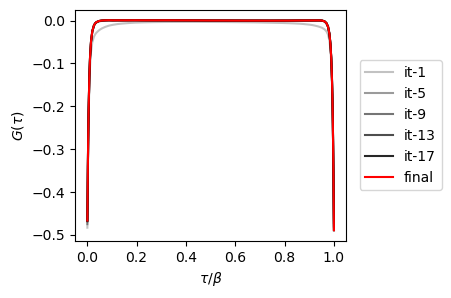

In [25]:
taus = np.load(os.path.expanduser(os.path.join(path, 'examples/1orbital/NN/example_inputs/taus.npy')))
taus = taus/np.max(taus)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
for iloop in range(1, G_dmft["n_its"]):
    if iloop in np.arange(1,20,4):
        ax.plot(taus, G_dmft[iloop]["G"][0,:,0], color = 'black', alpha = iloop/G_dmft["n_its"]*0.8 + 0.2, label=f'it-{iloop}') 

ax.plot(taus, G_dmft["final"]["G"][0,:,0], color = 'red', label='final')
ax.set_xlabel(r"$\tau/\beta$") 
ax.set_ylabel(r"$G(\tau)$")
ax.legend(loc='center', bbox_to_anchor=(1.2,0.5))
plt.savefig("Gtau.png")

### 4) Converting to TRIQS BlockGf
It can be useful to convert the neural-network output to TRIQS BlockGf object, in order to further analyze it or do other subsequent calculations. Here we convert the output into a block Green's function in DLR (ImTime/ImFreq) mesh and plot it.

In [26]:
from h5 import *
from triqs.gf import *
from triqs.gf.tools import *
from triqs.gf.meshes import MeshDLRImFreq
from triqs.plot.mpl_interface import oplot

from mldmft.utils import NNoutput_to_DLR, switch_mesh

Load reference mesh that has been used to train the neural network:

In [27]:
# transform the NN output into a DLR Green's function, however at reference beta=70
with HDFArchive(os.path.expanduser(os.path.join(path,f'models/orb1/mesh_beta{beta0:.0f}.h5')) ,'r') as h5:
    mesh_beta0 = h5['mesh_dlr_imtime']

output_dlr = NNoutput_to_DLR(outputs, mesh_beta0, sample_index=0) 

# switch beta to current beta by creating new grid and re-scaling
wmax_val = 10
eps_val = 1e-13
dlr_mesh_new = MeshDLRImTime(beta=beta, statistic='Fermion', w_max=wmax_val, eps=eps_val) # new DLR mesh at current value of beta
G_dlr = switch_mesh(output_dlr, beta_new=beta, beta_old=beta0, wmax_val=wmax_val, eps_val=eps_val)
#Get DLRImTime and DLRImFreq G
G_tau_dlr_NN = make_gf_dlr_imtime(G_dlr)
G_iw_dlr_NN = make_gf_dlr_imfreq(G_dlr)

We can now, for instance, use TRIQS plotting tools to plot the Green's function in Matsubara frequency space.

(-0.16, 0.0)

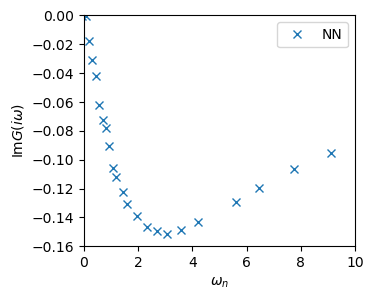

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
ax.oplot(G_iw_dlr_NN['up'].imag, label='NN')
ax.set_ylabel(r'Im$G(i\omega)$')
ax.set_xlim(0,10)
ax.set_ylim(-0.16,0)

## II. Comparison to CT-SEG results

### 1) Load CT-SEG results

In [29]:
tauvals = np.load(f'reference_outputs/tauvals_ctseg_u7.0.npy')
G_tau_ctseg = np.load(f'reference_outputs/gtau_ctseg_u7.0.npy')

### 2) Compare NN vs CT-SEG : Impurity Green's function

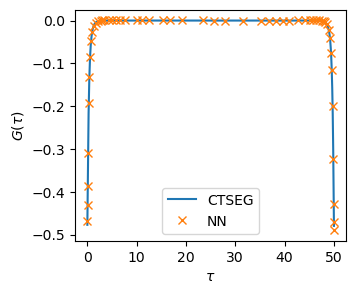

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
ax.plot(tauvals, G_tau_ctseg, label='CTSEG')
ax.oplot(G_tau_dlr_NN['up'][0,0].real, label='NN')
ax.set_ylabel(r'$G(\tau)$')
ax.legend(loc='lower center')

### 3) Get NN Self-energy from Dyson Equation
The self-energy $\Sigma(i\omega)$ can be obtained via Dyson Equation. Here, we'll explicitly solve Dyson equation to get the self-energy from the impurity Green's function $G$ obtained from NN solver, and compare it to CT-SEG result.

In [31]:
Sigma_imfreq_NN = G_iw_dlr_NN.copy()
eps_g_floor=1e-10  #Green's function cutoff for safe division

for om in G_iw_dlr_NN.mesh:
    iw = om.value.value  # complex: i * omega_n

    for sp in ['up', 'down']:
        Gval = G_iw_dlr_NN[sp][om][0,0]

        # Safety guard for division (rare but can happen if NN outputs junk at high freq)
        if abs(Gval) < eps_g_floor:
            # Keep something finite; you can also raise an error instead.
            Gval = eps_g_floor + 0j

        Delta_tmp = (t**2) * Gval
        Sigma_tmp = (iw + mu - Delta_tmp) - (1.0 / Gval)

        Sigma_imfreq_NN[sp][om][0,0] = Sigma_tmp


### 4) Plot Self-energy : Compare NN vs CT-SEG 

In [32]:
#Get CTSEG Self-energy
omvals = np.load(f'reference_outputs/omvals_ctseg_u7.0.npy')
Siom_ctseg = np.load(f'reference_outputs/siom_ctseg_u7.0.npy')

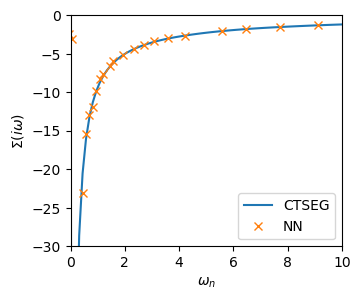

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
ax.plot(omvals, Siom_ctseg, label='CTSEG')
ax.oplot(Sigma_imfreq_NN['up'][0,0].imag, label='NN')

ax.set_ylabel(r'$\Sigma(i\omega)$')
ax.set_xlim(0,10)
ax.set_ylim(-30,0.)
ax.legend(loc='lower right')